# Parte 2: Práctica de Deep Learning e IA Generativa

In [2]:
import yfinance
import matplotlib.pyplot as plt
import torch
import numpy as np
import sys 
import os
from torch import nn

In [3]:
def set_device ():# definimos metodo para que seleccione la gpu en el caso de estar disponible
    if torch.backends.mps.is_available(): # para usar con mac silicon
        device = "mps"
    elif torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    torch.set_default_device(device)
    print(f"Using {torch.device(device)} device")
    return torch.device(device)

def sinu_constructed(x_min,x_max,numero_muestras,Amplitud,w,desfase=0): # definimos un método para crear sinusoides
    x = np.linspace(x_min,x_max,numero_muestras)
    y = Amplitud*np.sin(w*x + desfase)
    return x,y

## GRU

Hemos decidido que para predecir valores futuros de una serie temporal, lo mejor es usar redes recurrentes como GRU o LSTM. Por simplicidad vamos a usar GRU. La fortaleza de este tipo de modelos es que usan capas recurrentes donde la salida vuelve a entrar, por ellos es muy útil para predecir valores secuenciales donde la salida depende de entradas anteriores

In [4]:
class GRUMulti(torch.nn.Module):
    # definimos la clase GRU usando pytorch
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, H=20, dropout=0.0):
        # H es el numero de pasos que queremos predecir
        super().__init__()
        self.gru = torch.nn.GRU( # inicializamos el modelo 
            input_size=input_size, # cada instante de la secuencia tiene un valor(precio)
            hidden_size=hidden_size, # numero de neuronas en la capa oculta
            num_layers=num_layers, # numero de capas apiladas
            batch_first=True, # (batch,seq_len,features)
            dropout=dropout if num_layers > 1 else 0.0 # regularización entre las capas de la GRU(activa y desactiva neuronas aletoriamente)
        )
        self.head = torch.nn.Linear(hidden_size, H) # capa lineal que transforma el último estado oculto en un vector de tamaño H

    def forward(self, x): # devuelve las H predicciones futuras
        out, _ = self.gru(x)         # (B,L,Hid)
        h_last = out[:, -1, :]       # (B,Hid)
        y = self.head(h_last)        # (B,H)
        return y

In [5]:
# definimos un loader de batches, pensado para recibir tensores ya cargados
class TensorLoader:

    def __init__(self, X, Y, bs=None, shuffle=True):
        self.X = X # entradas
        self.Y = Y # salidas
        self.len = len(X) # tamaño de la sequencia 

        self.bs = bs if bs else self.len #tamaño del batch, si no se indica nada único batch
        self.shuffle = shuffle # si mezcla datos o no

        self.nbatch = (self.len + self.bs - 1) // self.bs # numero de batches
        self.device = X.device # device del tensor x ya cargado previamente

        self.reset() #inicializamos el iterador

    def reset(self):
        self.p0 = 0 # posicion inicial
        if self.shuffle:
            self.idx = torch.randperm(self.len, device=self.device) # si hay suffle genera permutacion aleatoria de indices (mezcla batches)
        else:
            self.idx = None # si no hay usará slices secuenciales

    def next(self):

        pf = min(self.p0 + self.bs, self.len) # calcula el indice final de batch
        if self.idx is None: # si no hay suffle, carga la x,y del batch
            xb = self.X[self.p0:pf]
            yb = self.Y[self.p0:pf]
        else:
            ids = self.idx[self.p0:pf] # selecciona los indices del batch
            xb = self.X[ids] # carga la x mezaclada
            yb = self.Y[ids] #carga la y mezclada

        self.p0 = pf # avanzamos en la secuencia 
        if self.p0 >= self.len: # si terminamos que vuelva a la posicion inicial
            self.reset()

        return xb, yb # devolvemos el batch escogido


    @staticmethod
    def train(X, Y, model, loss_fn, optimizer,
              epochs=200, bs=64, device="cuda", trace=20):

        # mover dataset a GPU una sola vez
        X = X.to(device)
        Y = Y.to(device)

        dataloader = TensorLoader(X, Y, bs=bs, shuffle=True) # cargamos el la X,Y de entrenamiento en nuestro tensor que generará batches

        model = model.to(device) # enviamos el modela a la GPU

        for e in range(epochs): # bucle de entrenamiento por épocas
            model.train() # pone el modo train activo
            acum_loss = 0 # perdida acumulada

            for _ in range(dataloader.nbatch): # por cada batch
                xb, yb = dataloader.next() # cargamos el batch
                optimizer.zero_grad(set_to_none=True) # limpia gradientes anteriores
                pred = model(xb) # hace la prediccion del batch
                loss = loss_fn(pred, yb) # calcula la perdida 
                loss.backward() # calcula gradientes de backpropagation 
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # hacemos clipping de gradiente(limitamos la norma de los gradientes a 1 para evitar explosiones)
                optimizer.step() # actualizamos los pesos del modelo
                acum_loss += loss.item() # perdida acumulada
                
            if (e+1) % trace == 0:
                print(f"loss: {acum_loss/dataloader.nbatch:>10f} [{e+1:>5d}/{epochs:>5d}]")

In [6]:
device = set_device() # seleccionamos el device

def make_windows_multistep(series, L=30, H=20): # creamos una serie de ventanas para que la X tenga un Y sobre la que predecir
    X, Y = [], []
    T = len(series)
    for t in range(T - L - H + 1):
        X.append(series[t:t+L]) # tamaño de datos de entrada (L)
        Y.append(series[t+L:t+L+H]) # tamaño de datos futuros H
    X = np.array(X, dtype=np.float32)[:, :, None] # convierte a array y añade versión final de feature
    Y = np.array(Y, dtype=np.float32) # convierte Y a array
    return X, Y

@torch.no_grad()
def predict_blocks(model, seed_series, L, total_steps, H, device="cuda"): # predecimos pasos futuros, es una predicción autoregresiva de bloques
    model.eval() # activamos el modo evaluación 
    seed = list(seed_series.astype(np.float32)) #copia la serie inicial como lista mutable 
    preds = [] # aqui guarda las predicciones
    while len(preds) < total_steps: # sigue hasta tener suficientes pasos predichos
        window = torch.tensor(seed[-L:], dtype=torch.float32, device=device).view(1, L, 1) # toma última L muestras del seed y las convierte en tensor
        block = model(window).squeeze(0).detach().cpu().numpy().tolist() # predice bloque de H valores y los pasa a lista
        need = total_steps - len(preds) # calcula cuantos faltan
        block = block[:need] # si el ultimo se pasa lo recorta
        preds.extend(block) # añade las predecciones al resultado final
        seed.extend(block) # añade las predicciones al histórico para seguir prediciendo
    return np.array(preds, dtype=np.float32) # devuelve un array de predicciones

Using cuda device


# Parte 1: Predecir los valores de la sinusoidal

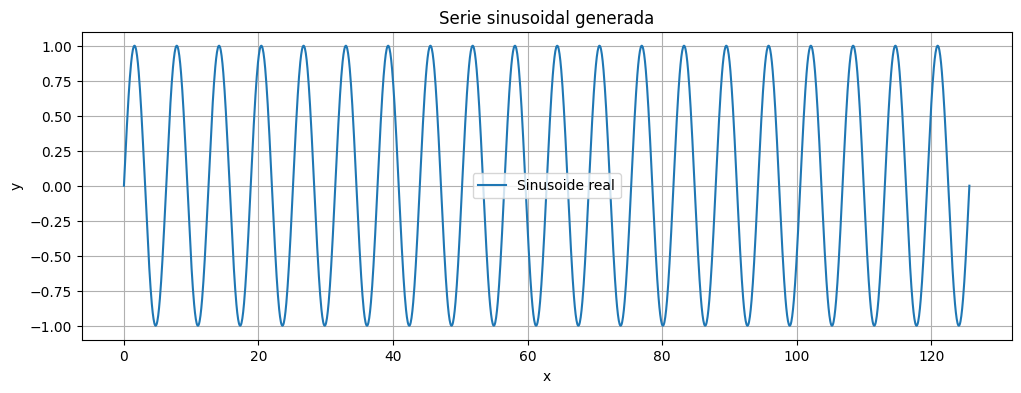

loss:   0.001144 [   20/  300]
loss:   0.000469 [   40/  300]
loss:   0.000311 [   60/  300]
loss:   0.000233 [   80/  300]
loss:   0.000386 [  100/  300]
loss:   0.000214 [  120/  300]
loss:   0.000122 [  140/  300]
loss:   0.000096 [  160/  300]
loss:   0.000151 [  180/  300]
loss:   0.000134 [  200/  300]
loss:   0.000114 [  220/  300]
loss:   0.000196 [  240/  300]
loss:   0.000070 [  260/  300]
loss:   0.000083 [  280/  300]
loss:   0.000078 [  300/  300]


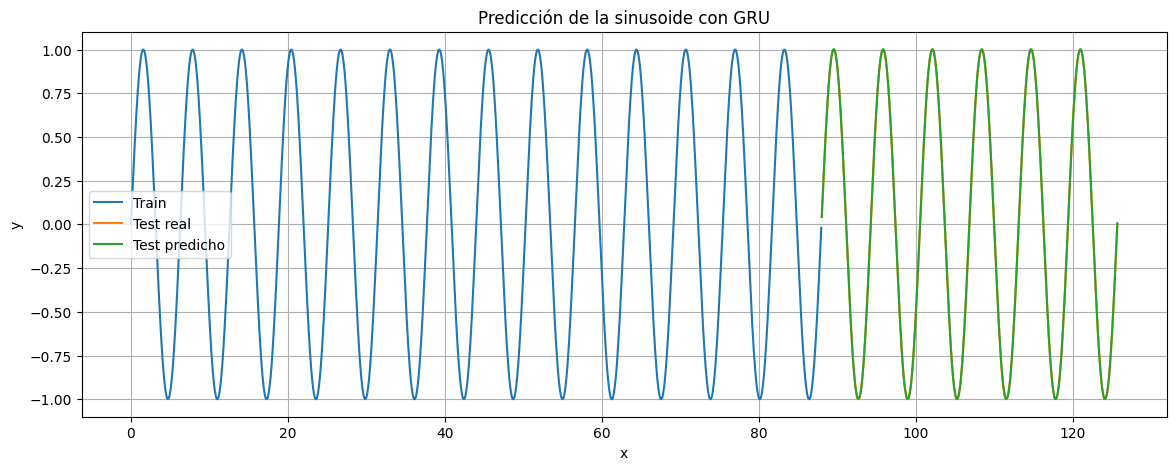

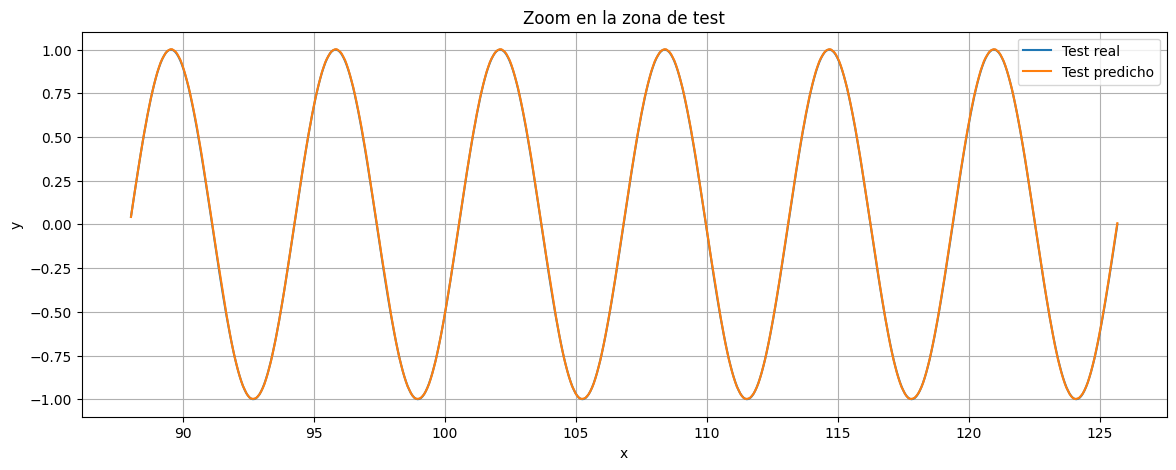

MSE test : 1.5851795301308646e-05
RMSE test: 0.003981431313147151


In [10]:
# Creamos una sinusoide de ejemplo
x, y = sinu_constructed(
    x_min=0,
    x_max=40*np.pi,
    numero_muestras=2000,
    Amplitud=1.0,
    w=1.0,
    desfase=0.0
)

plt.figure(figsize=(12, 4))
plt.plot(x, y, label="Sinusoide real")
plt.title("Serie sinusoidal generada")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

# Split train/test
cut = int(len(y) * 0.7)
train = y[:cut]
test = y[cut:]
x_train = x[:cut]
x_test = x[cut:]

# Normalización con estadísticos del train
mu = train.mean()
sig = train.std() + 1e-8
train_z = (train - mu) / sig
test_z = (test - mu) / sig

# Ventanas supervisadas
L = 50
H = 20
X_np, Y_np = make_windows_multistep(train_z, L=L, H=H)

# Tensores
X_t = torch.tensor(X_np, dtype=torch.float32)
Y_t = torch.tensor(Y_np, dtype=torch.float32)

# Modelo
model = GRUMulti(
    input_size=1,
    hidden_size=64,
    num_layers=2,
    H=H,
    dropout=0.1
)

# Loss + optimizador
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Entrenamiento
TensorLoader.train(
    X_t,
    Y_t,
    model,
    loss_fn,
    optimizer,
    epochs=300,
    bs=64,
    device=device,
    trace=20
)

# Predicción del test
pred_test_z = predict_blocks(
    model,
    seed_series=train_z,
    L=L,
    total_steps=len(test_z),
    H=H,
    device=device
)

# Desnormalización
pred_test = pred_test_z * sig + mu

# Gráfica completa
plt.figure(figsize=(14, 5))
plt.plot(x_train, train, label="Train")
plt.plot(x_test, test, label="Test real")
plt.plot(x_test, pred_test, label="Test predicho")
plt.title("Predicción de la sinusoide con GRU")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

# Zoom en test
plt.figure(figsize=(14, 5))
plt.plot(x_test, test, label="Test real")
plt.plot(x_test, pred_test, label="Test predicho")
plt.title("Zoom en la zona de test")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

# Métricas
mse_test = np.mean((pred_test - test)**2)
rmse_test = np.sqrt(mse_test)

print("MSE test :", mse_test)
print("RMSE test:", rmse_test)

# Parte 2: Predecir los valores de las acciones de una empresa

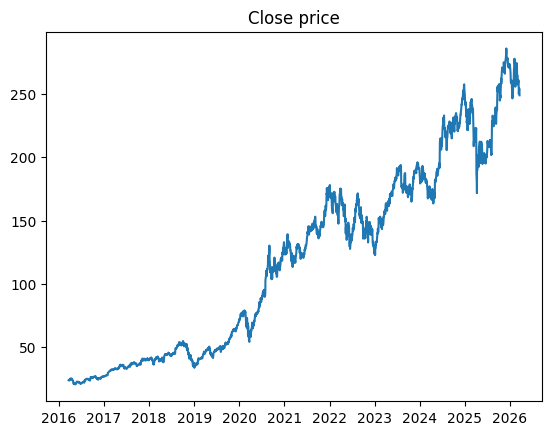

loss:   0.967647 [   20/  600]
loss:   0.812420 [   40/  600]
loss:   0.663812 [   60/  600]
loss:   0.540787 [   80/  600]
loss:   0.433377 [  100/  600]
loss:   0.335914 [  120/  600]
loss:   0.260843 [  140/  600]
loss:   0.206034 [  160/  600]
loss:   0.168271 [  180/  600]
loss:   0.141377 [  200/  600]
loss:   0.113843 [  220/  600]
loss:   0.092241 [  240/  600]
loss:   0.079682 [  260/  600]
loss:   0.070215 [  280/  600]
loss:   0.062441 [  300/  600]
loss:   0.055660 [  320/  600]
loss:   0.050717 [  340/  600]
loss:   0.046473 [  360/  600]
loss:   0.043134 [  380/  600]
loss:   0.040373 [  400/  600]
loss:   0.037829 [  420/  600]
loss:   0.035614 [  440/  600]
loss:   0.033731 [  460/  600]
loss:   0.032132 [  480/  600]
loss:   0.031268 [  500/  600]
loss:   0.029456 [  520/  600]
loss:   0.028125 [  540/  600]
loss:   0.027288 [  560/  600]
loss:   0.026379 [  580/  600]
loss:   0.025117 [  600/  600]
pred: [150.33061 149.98956 149.87639 149.79515 149.23828] ... [332.209

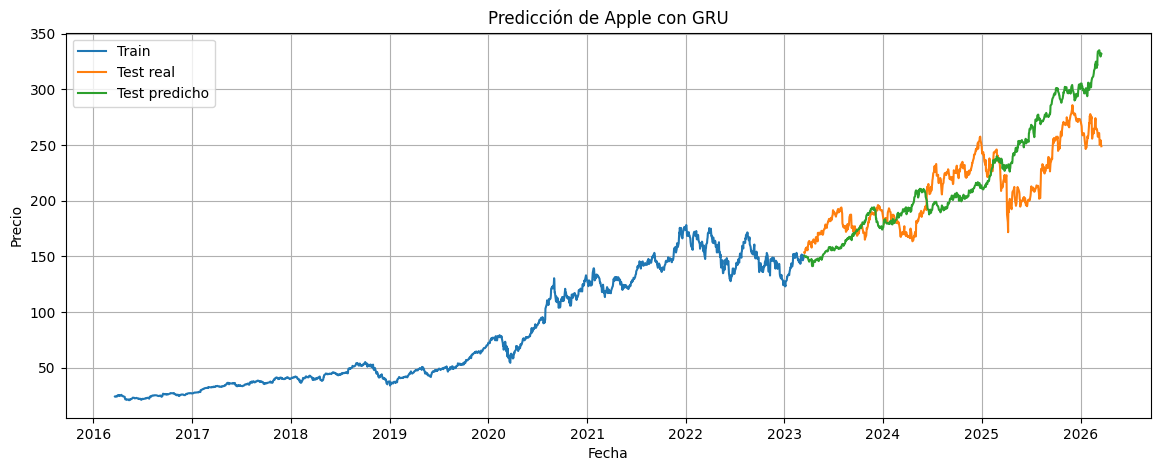

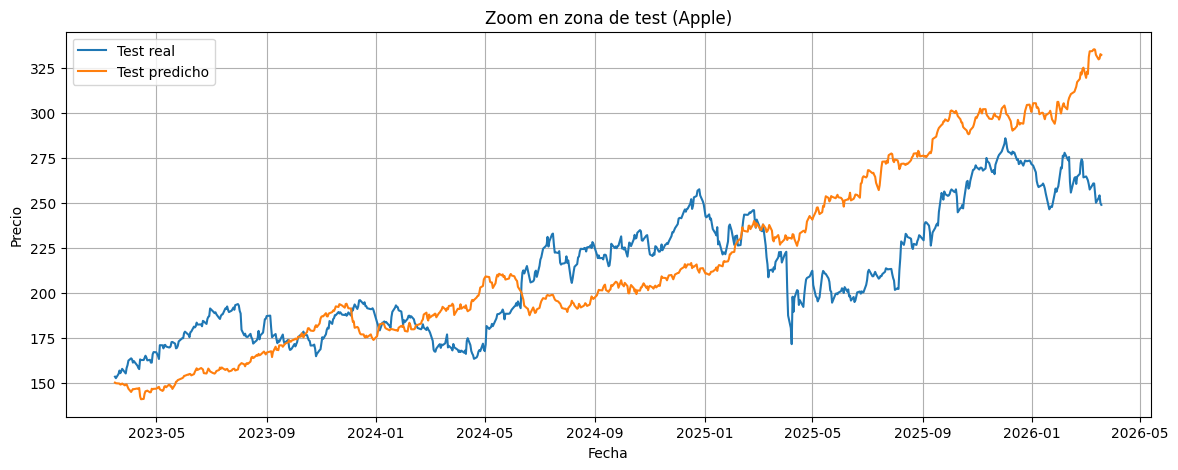

MSE : 963.5839490977412
RMSE: 31.041648620808484


In [12]:
#Cargamos los datos de la empresa Apple de los últimos 10 años

data = yfinance.Ticker("AAPL")
ten_years = data.history(period="10y")

ten_years = ten_years[["Close"]].iloc[:-1]
a = int(len(ten_years)*0.7)
train = ten_years.iloc[:a] # separamos en datos de train y test
test  = ten_years.iloc[a:]

plt.plot(ten_years.index, ten_years["Close"])
plt.title("Close price")
plt.show()

# 1) prices -> log-returns hacemos esto para que sean más estables las predicciones del modelo, trabajamos mejor sobre logaritmos
p = train["Close"].values.astype(np.float32)
logp = np.log(p + 1e-8)
r = np.diff(logp)# length T-1

# 2) ademas normalizamos para conseguir todavía mayor estabilidad
mu_r = r.mean()
sig_r = r.std() + 1e-8
r_z = (r - mu_r) / sig_r

#creamos las ventanas 
L, H = 30, 20
X_np, Y_np = make_windows_multistep(r_z, L=L, H=H)
# Pasamos a tensores
x = torch.tensor(X_np)
y = torch.tensor(Y_np)

# inicializamos el modelo y definimos las funciones de pérdida y el optimizador de los parámetros del modelo
model = GRUMulti(hidden_size=64, num_layers=2, H=H, dropout=0.1)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#Entrenamos el modelo
TensorLoader.train(
    x, y,
    model,
    loss_fn,
    optimizer,
    epochs=600,
    bs=64,
    device=device,
    trace=20
)

# predice returns normalizados
pred_r_z = predict_blocks(model, r_z, L=L, total_steps=len(test), H=H, device=device)

# desnormaliza returns
pred_r = pred_r_z * sig_r + mu_r

# reconstruye precios desde el último precio del train
p0 = train["Close"].values.astype(np.float32)[-1]
logp0 = np.log(p0 + 1e-8)
r_train = np.diff(np.log(train["Close"].values.astype(np.float32) + 1e-8))
r_mean_train = r_train.mean()

pred_r = pred_r - pred_r.mean() + r_mean_train
logp_pred = logp0 + np.cumsum(pred_r)
pred_price = np.exp(logp_pred)

print("pred:", pred_price[:5], "...", pred_price[-5:])
print("true:", test["Close"].values[:5], "...", test["Close"].values[-5:])

#plots para visualizar los resultados del modelo
plt.figure(figsize=(14, 5))
plt.plot(train.index, train["Close"].values, label="Train") 
plt.plot(test.index, test["Close"].values, label="Test real")
plt.plot(test.index, pred_price, label="Test predicho")

plt.title("Predicción de Apple con GRU")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(14, 5))

plt.plot(test.index, test["Close"].values, label="Test real")
plt.plot(test.index, pred_price, label="Test predicho")

plt.title("Zoom en zona de test (Apple)")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid()

plt.show()

# devolvemos además unas pocas métricas de nuestra predección
mse = np.mean((pred_price - test["Close"].values)**2)
rmse = np.sqrt(mse)

print("MSE :", mse)
print("RMSE:", rmse)

In [ ]:
torch.save(model.state_dict(), "gru_stock_predictions.pt")

# Conclusiones

## De nuestro modelo podemos sacar varias conclusiones a tener en cuenta:

# 1.Parte sinusoide

Al ser una función muy sencilla y con poco ruido, vemos que las predicciones de nuestro modelo son perfectas y que se adapta perfectamente como esperábamos a la forma del sinusoide. El modelo cumple con lo esperado.

# 2.Parte Stock

Para poder sacar conclusiones de estos resultados hemos de tener en cuenta que estamos tratando de predecir valores futuros de la empresa Apple. Por ello, hay que tener en cuenta que la bolsa tiene un montón de subidas y bajadas que son prácticamente imposibles de predecir, por ello, lo que se busca no es tratar de predecir toda la función precio de la acción, sino ser capaz de distinguir las tendencias de crecimiento a largo plazo. Se puede observar que nuestro modelo cumple con esta labor ya que si nos fijamos durante los dos-tres primero años se entrecruza con la función del precio lo que nos hace entender que realmente se está aprendiendo y complementa una serie de predicciones áltamente realistas. Por ejemplo vemos que tras un año nuestro modelo coincide con el precio de las acciones reales, vuelve hacerlo a los dos años, y aunque es cierto que el último ya empeora un poco, lo que es normal porque tres años vista es un tiempo de predicción muy alejado, no difiere en exceso con el valor real. Decir que tb es cierto que muy al final se aprecia desviaciones críticas que y indican un mal ajuste en esa zona. En general, las predicciones del modelo son realistas y logran aprender las tendencias de crecimiento subyacentes en el precio de la acción

